# Data Engineer — Data Quality Assessment  
### NovaCred Credit Applications Dataset

This notebook audits `raw_credit_applications.json` across key data quality dimensions to ensure the dataset is reliable for downstream bias analysis.

| # | Dimension | Significance |
|-|-----------|--------------------------|
| 1 | **Completeness** | Missing fields can exclude groups unevenly | 
| 2 | **Consistency** | Inconsistent encoding breaks grouping (e.g., gender) | 
| 3 | **Validity** | Out-of-range values distort risk + fairness metrics | 
| 4 | **Accuracy / Uniqueness** | Duplicates can skew approval rates + group stats |



---

---

## 1. Initial Setup

This section prepares the environment for the analysis by importing the required libraries and setting up the workspace. These tools will be used throughout the notebook to load, inspect, and evaluate the dataset.

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import re
from pathlib import Path
import os

pd.set_option("display.max_columns", None)

---

## 2. Data Loading and Initial Exploration

The dataset is loaded into the Python environment and inspected to understand its structure. Reviewing column names, data types, and sample observations helps identify any immediate irregularities in the data.

### 2.1 - Load Dataset

In [5]:
# Load the dataset

data_path = Path("../data/raw_credit_applications.json")

df = pd.read_json(data_path)

# Show dataset shape
df.shape

(502, 8)

### 2.2 - Open Dataset

In [6]:
# Load raw JSON
with open(data_path, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

# Flatten nested structure into columns
df_original = pd.json_normalize(raw_data)

# Working copy for analysis/cleaning
df = df_original.copy()

print("Dataset loaded successfully")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

df.head()

Dataset loaded successfully
Shape: 502 rows, 21 columns


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,73000,23,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,M,1992-03-31,10032,78000,51,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,61000,41,0.21,37909,True,NaN,vacation,3.7,59000.0,NaN,NaN
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077,103000,70,0.35,0,True,NaN,NaN,4.3,34000.0,NaN,NaN
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,M,1999-05-21,10080,57000,14,0.23,31763,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN


### 2.3 - Quick exploration

In [ ]:
df.info()
df.describe(include="all").T.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   _id                               502 non-null    object 
 1   spending_behavior                 502 non-null    object 
 2   processing_timestamp              62 non-null     object 
 3   applicant_info.full_name          502 non-null    object 
 4   applicant_info.email              502 non-null    object 
 5   applicant_info.ssn                497 non-null    object 
 6   applicant_info.ip_address         497 non-null    object 
 7   applicant_info.gender             501 non-null    object 
 8   applicant_info.date_of_birth      501 non-null    object 
 9   applicant_info.zip_code           501 non-null    object 
 10  financials.annual_income          497 non-null    object 
 11  financials.credit_history_months  502 non-null    int64  
 12  financia

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
_id,502,500,app_001,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
spending_behavior,502,496,"[{'category': 'Insurance', 'amount': 171}]",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
processing_timestamp,62,4,2024-01-15T00:00:00Z,59,NaN,NaN,NaN,NaN,NaN,NaN,NaN
applicant_info.full_name,502,475,Susan Flores,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
applicant_info.email,502,494,,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
applicant_info.ssn,497,494,652-70-5530,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
applicant_info.ip_address,497,496,192.168.91.142,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
applicant_info.gender,501,5,Male,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
applicant_info.date_of_birth,501,494,,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
applicant_info.zip_code,501,196,10048,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

# 3. Completeness Analysis

In this section we examine whether important fields contain missing values.

Missing data can introduce bias or reduce the reliability of the dataset.  
For example:

- Missing **income** can affect credit risk modeling
- Missing **gender** can distort fairness analysis
- Missing **timestamps** can break audit trails
- Missing **PII fields** like email or SSN may indicate incomplete applications

We first measure how many values are missing for each key column.

### 3.1 - Find Missing Values

In [14]:
# Missingness summary 
missing_summary = pd.DataFrame({
    "Column": df_clean.columns,
    "Missing_Count": df_clean.isna().sum().values,
    "Missing_%": (df_clean.isna().mean() * 100).round(1).values
}).sort_values("Missing_%", ascending=False).reset_index(drop=True)

missing_summary.head(20)

,Column,Missing_Count,Missing_%
0,notes,500,99.6
1,financials.annual_salary,497,99.0
2,loan_purpose,452,90.0
3,processing_timestamp,440,87.6
4,decision.rejection_reason,292,58.2
5,decision.interest_rate,210,41.8
6,decision.approved_amount,210,41.8
7,applicant_info.email,7,1.4
8,applicant_info.ssn,5,1.0
9,financials.annual_income,5,1.0


The table above shows the number and percentage of missing values for each field.

This helps identify which variables may require special handling before the dataset can be used for modeling.

Some fields require different treatment depending on their role:

- **Protected attributes** such as gender should never be imputed.
- **Financial variables** such as income should generally not be guessed or filled artificially.
- **PII fields** such as email and SSN should be flagged but not automatically modified.

In the next step we create flags that record which records have missing values.

### 3.2 - Standardize Missing Values

Datasets often contain multiple representations of missing data.  
Examples include empty strings (`""`), `"NA"`, `"N/A"`, `"null"`, or `"unknown"`.

Having inconsistent missing-value formats can create problems during analysis because these values may not be recognized as missing by Python or pandas.

To ensure consistency, we standardize all missing-value representations so that they appear as `NaN`. This allows pandas functions such as `.isna()` and `.dropna()` to correctly detect missing data.

In [15]:
df_clean = df.copy()

# Standard placeholders that should count as missing (case-insensitive)
placeholders = {
    "", " ", "NA", "N/A", "NULL", "null", "None", "none", "nan", "NaN"
}

# Replace exact placeholders
df_clean = df_clean.replace(list(placeholders), np.nan)

# Also convert strings that are just whitespace ("   ") into NaN
df_clean = df_clean.replace(r"^\s+$", np.nan, regex=True)

# Quick check: top missing columns after standardization
df_clean.isna().sum().sort_values(ascending=False).head(15)

notes                           500
financials.annual_salary        497
loan_purpose                    452
processing_timestamp            440
decision.rejection_reason       292
decision.interest_rate          210
decision.approved_amount        210
applicant_info.email              7
applicant_info.ssn                5
financials.annual_income          5
applicant_info.date_of_birth      5
applicant_info.ip_address         5
applicant_info.gender             3
applicant_info.zip_code           2
applicant_info.full_name          0
dtype: int64

The table above shows the number of missing values present in each column after standardization.

By converting different placeholders into a single representation (`NaN`), the dataset becomes easier to analyze and cleaner to work with. All missing values are now handled consistently across the dataset.

This step does not modify valid data, but it ensures that incomplete entries are clearly identified for later data quality checks.

### 3.3 - Missing Values Visualization

To better understand the completeness of the dataset, we visualize the number of missing values.

This allows us to quickly identify which attributes contain the highest amount of missing data and which fields are largely complete.

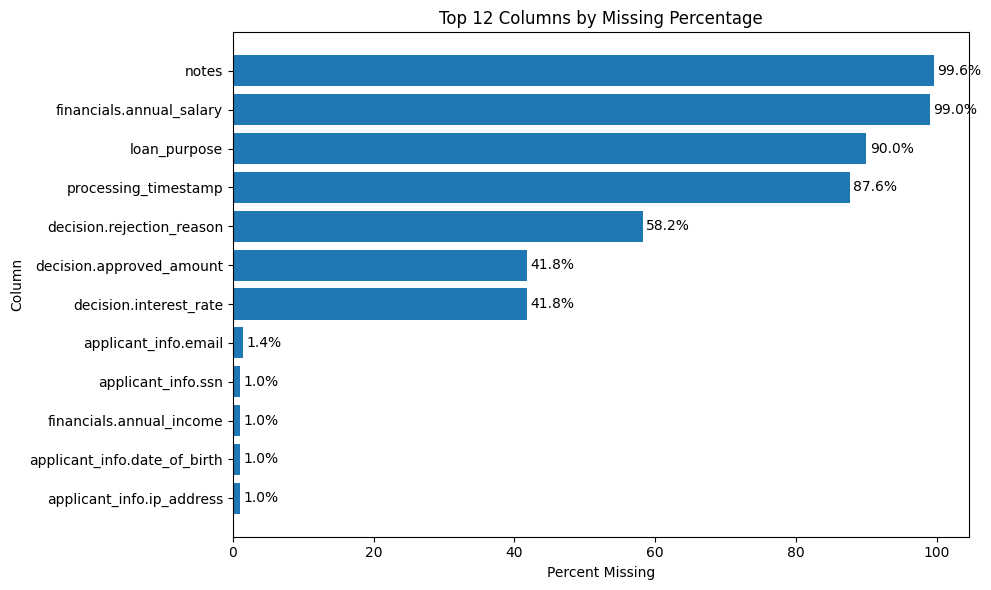

In [ ]:
import matplotlib.pyplot as plt

top_n = 12  # adjust if you want more/less columns
plot_df = missing_summary.head(top_n).sort_values("Missing_%")  # sort so bars go smallest->largest

plt.figure(figsize=(10, 6))
plt.barh(plot_df["Column"], plot_df["Missing_%"])

plt.title(f"Top {top_n} Columns by Missing Percentage")
plt.xlabel("Percent Missing")
plt.ylabel("Column")

# Add value labels
for i, v in enumerate(plot_df["Missing_%"]):
    plt.text(v + 0.5, i, f"{v:.1f}%", va="center")

plt.tight_layout()
plt.show()

---

## 4. Consistency Analysis

Consistency refers to whether data values follow expected formats and logical rules across the dataset.

In this section, we evaluate whether key identifiers are unique and whether values are consistently recorded across variables.

### 4.1 Inspect Data Types

Consistency problems often occur when variables are stored in the wrong format.
For example, numeric values may appear as strings or dates may appear as text.

We begin by inspecting the data types of all columns in the dataset.

In [33]:
df_clean.dtypes

_id                                              object
spending_behavior                                object
processing_timestamp                datetime64[ns, UTC]
applicant_info.full_name                         object
applicant_info.email                             object
applicant_info.ssn                               object
applicant_info.ip_address                        object
applicant_info.gender                    string[python]
applicant_info.date_of_birth             datetime64[ns]
applicant_info.zip_code                  string[python]
financials.annual_income                        float64
financials.credit_history_months                  int64
financials.debt_to_income                       float64
financials.savings_balance                        int64
decision.loan_approved                             bool
decision.rejection_reason                        object
loan_purpose                                     object
decision.interest_rate                          

The table above shows the current data types for each column.

Fields that represent numeric quantities or dates should be stored in numeric or datetime formats rather than strings. In the following steps we standardize these fields to ensure consistent data representation.

### 4.2 Consistency Check for Key Fields

Before applying any corrections, we first inspect the main fields that are most likely to contain consistency issues.

The goal of this step is to identify whether values are stored in a uniform format across the dataset.  
The following fields are checked because they are important for downstream analysis and fairness evaluation:

- `applicant_info.gender`
- `applicant_info.date_of_birth`
- `processing_timestamp`
- `applicant_info.zip_code`
- `financials.annual_income`

For each field, we review the current data type, example values, and whether standardization is needed.

In [34]:
# Key fields to inspect for consistency
key_fields = [
    "applicant_info.gender",
    "applicant_info.date_of_birth",
    "processing_timestamp",
    "applicant_info.zip_code",
    "financials.annual_income"
]

consistency_rows = []

for col in key_fields:
    if col not in df_clean.columns:
        consistency_rows.append({
            "Column": col,
            "Exists": "No",
            "Current_Dtype": "Not found",
            "Non_Null_Count": 0,
            "Unique_Values": 0,
            "Sample_Values": "Column not found",
            "Needs_Standardization": "Unknown"
        })
        continue

    non_null = df_clean[col].dropna()
    sample_values = non_null.astype(str).unique()[:5]

    needs_standardization = "No"

    if col == "applicant_info.gender":
        values = set(non_null.astype(str).str.strip().unique())
        if values != {"Male", "Female"} and values != {"Male", "Female", "Unknown"}:
            needs_standardization = "Yes"

    elif col == "applicant_info.date_of_birth":
        raw_values = non_null.astype(str).str.strip()
        format_count = 0
        format_count += raw_values.str.match(r"^\d{4}-\d{2}-\d{2}$").any()
        format_count += raw_values.str.match(r"^\d{4}/\d{2}/\d{2}$").any()
        format_count += raw_values.str.match(r"^\d{2}/\d{2}/\d{4}$").any()
        if format_count > 1 or str(df_clean[col].dtype) != "datetime64[ns]":
            needs_standardization = "Yes"

    elif col == "processing_timestamp":
        if "datetime" not in str(df_clean[col].dtype):
            needs_standardization = "Yes"

    elif col == "applicant_info.zip_code":
        if str(df_clean[col].dtype) != "object" and str(df_clean[col].dtype) != "string":
            needs_standardization = "Yes"
        elif non_null.astype(str).str.contains(r"\.0$", regex=True).any():
            needs_standardization = "Yes"

    elif col == "financials.annual_income":
        if "float" not in str(df_clean[col].dtype) and "int" not in str(df_clean[col].dtype):
            needs_standardization = "Yes"

    consistency_rows.append({
        "Column": col,
        "Exists": "Yes",
        "Current_Dtype": str(df_clean[col].dtype),
        "Non_Null_Count": int(non_null.shape[0]),
        "Unique_Values": int(non_null.nunique()),
        "Sample_Values": ", ".join(sample_values),
        "Needs_Standardization": needs_standardization
    })

consistency_check = pd.DataFrame(consistency_rows)
consistency_check

print("Gender values:")
display(df_clean["applicant_info.gender"].value_counts(dropna=False))

print("\nSample date_of_birth values:")
display(df_clean["applicant_info.date_of_birth"].dropna().astype(str).head(10))

print("\nSample processing_timestamp values:")
display(df_clean["processing_timestamp"].dropna().astype(str).head(10))

print("\nSample zip_code values:")
display(df_clean["applicant_info.zip_code"].dropna().astype(str).head(10))

print("\nSample annual_income values:")
display(df_clean["financials.annual_income"].dropna().astype(str).head(10))

Gender values:


applicant_info.gender
Female    251
Male      248
<NA>        3
Name: count, dtype: Int64


Sample date_of_birth values:


0     2001-03-09
1     1992-03-31
2     1989-10-24
3     1983-04-25
4     1999-05-21
7     1991-10-11
8     1990-05-04
9     1989-10-10
10    1970-10-01
12    1989-06-13
Name: applicant_info.date_of_birth, dtype: object


Sample processing_timestamp values:


0     2024-01-15 00:00:00+00:00
4     2024-01-15 00:00:00+00:00
21    2024-01-15 00:00:00+00:00
31    2024-01-15 00:00:00+00:00
37    2024-01-15 00:00:00+00:00
43    2024-01-15 00:00:00+00:00
46    2024-01-15 00:00:00+00:00
55    2024-01-15 00:00:00+00:00
59    2024-01-15 00:00:00+00:00
67    2024-01-15 00:00:00+00:00
Name: processing_timestamp, dtype: object


Sample zip_code values:


0    10036
1    10032
2    10075
3    10077
4    10080
5    10019
6    10022
7    90223
8    10044
9    10080
Name: applicant_info.zip_code, dtype: object


Sample annual_income values:


0     73000.0
1     78000.0
2     61000.0
3    103000.0
4     57000.0
5    110000.0
6     55000.0
7     82000.0
8     69000.0
9     55000.0
Name: financials.annual_income, dtype: object

### 4.3 Standardizing Gender Values

Gender should use one consistent set of categories.  
In this dataset, gender appears in multiple encodings (e.g., `"M"`, `"F"`, `"Male"`, `"Female"`).  
We normalize these values so that gender is consistently represented.

In [30]:
df_clean["applicant_info.gender"].value_counts(dropna=False)

df_clean["applicant_info.gender"] = (
    df_clean["applicant_info.gender"]
    .astype("string")
    .str.strip()
    .str.title()   # "male" -> "Male"
)

df_clean["applicant_info.gender"] = df_clean["applicant_info.gender"].replace({
    "M": "Male",
    "F": "Female"
})

df_clean["applicant_info.gender"].value_counts(dropna=False)

applicant_info.gender
Female    251
Male      248
<NA>        3
Name: count, dtype: Int64

After standardization, gender values now follow a consistent format using the categories "Male" and "Female".

Standardizing protected attributes such as gender ensures accurate fairness analysis and prevents incorrect grouping during statistical calculations.

### 4.4 Standardizing Date of Birth Format

Dates can appear in different string formats (e.g., `YYYY-MM-DD`, `YYYY/MM/DD`, `MM/DD/YYYY`).  
To avoid misinterpretation, we convert the date_of_birth field into a proper datetime format.

In [29]:
df_clean["applicant_info.date_of_birth"].dropna().astype(str).head(10)

dob = df_clean["applicant_info.date_of_birth"].astype("string").str.strip()

dob_1 = pd.to_datetime(dob, format="%Y-%m-%d", errors="coerce")
dob_2 = pd.to_datetime(dob, format="%Y/%m/%d", errors="coerce")
dob_3 = pd.to_datetime(dob, format="%m/%d/%Y", errors="coerce")

df_clean["applicant_info.date_of_birth"] = dob_1.fillna(dob_2).fillna(dob_3)

df_clean["applicant_info.date_of_birth"].head(10)

0   2001-03-09
1   1992-03-31
2   1989-10-24
3   1983-04-25
4   1999-05-21
5          NaT
6          NaT
7   1991-10-11
8   1990-05-04
9   1989-10-10
Name: applicant_info.date_of_birth, dtype: datetime64[ns]

### 4.5 Converting Financial Fields to Numeric Format

Financial attributes such as income should be stored as numeric values rather than strings.

If these values remain as text, calculations such as averages or ratios cannot be performed correctly.

In [19]:
df_clean["financials.annual_income"] = pd.to_numeric(
    df_clean["financials.annual_income"], errors="coerce"
)

df_clean["financials.annual_income"].dtype

dtype('float64')

The income field has now been converted to a numeric data type.

This ensures that financial variables can be used in statistical calculations and modeling without errors caused by inconsistent data types.

### 4.6 Standardizing Processing Timestamp

The processing timestamp is used for auditability and tracking when an application was handled.  
We convert it into a datetime format so it can be used for sorting, filtering, and time-based analysis.

In [28]:
df_clean["processing_timestamp"].dropna().astype(str).head(10)

ts = df_clean["processing_timestamp"].astype("string").str.strip()

# Allow common ISO-like timestamps; anything else becomes NaT
df_clean["processing_timestamp"] = pd.to_datetime(ts, errors="coerce")

df_clean["processing_timestamp"].head(10)

0   2024-01-15 00:00:00+00:00
1                         NaT
2                         NaT
3                         NaT
4   2024-01-15 00:00:00+00:00
5                         NaT
6                         NaT
7                         NaT
8                         NaT
9                         NaT
Name: processing_timestamp, dtype: datetime64[ns, UTC]

### 4.7 Standardizing ZIP Code Formatting

ZIP codes may look numeric but they are identifiers, not quantities.  
We keep them as text and normalize formatting (trim whitespace, remove decimals, preserve leading zeros when possible).

In [27]:
df_clean["applicant_info.zip_code"].dropna().astype(str).head(10)

zip_raw = df_clean["applicant_info.zip_code"].astype("string").str.strip()

# Remove trailing ".0" if ZIP came from numeric parsing
zip_clean = zip_raw.str.replace(r"\.0$", "", regex=True)

# Keep only digits (optional, but makes it uniform)
zip_clean = zip_clean.str.replace(r"[^0-9]", "", regex=True)

df_clean["applicant_info.zip_code"] = zip_clean

df_clean["applicant_info.zip_code"].dropna().head(10)

0    10036
1    10032
2    10075
3    10077
4    10080
5    10019
6    10022
7    90223
8    10044
9    10080
Name: applicant_info.zip_code, dtype: string

---

## 5. Accuracy Analysis

In this section we examine whether the dataset contains inaccurate or duplicate records.

Inaccurate data can distort analytical results and lead to incorrect conclusions.  
For example:

- Duplicate application records can inflate dataset size and bias statistical results
- Duplicate unique identifiers (`_id`) may indicate data ingestion or processing errors
- Reused Social Security Numbers (SSNs) across multiple applicants may indicate duplicate applications or identity conflicts

Ensuring record-level accuracy is critical for maintaining dataset integrity and reliable downstream analysis.

We first check for duplicate records and identifier conflicts across the dataset.

### 5.1 Duplicate Record Detection

Duplicate records can inflate dataset size and distort statistical results.  
We first check whether any records appear more than once in the dataset.

In [38]:
# Check duplicate application IDs
duplicate_rows = df_clean["_id"].duplicated().sum()

print("Duplicate application IDs:", duplicate_rows)

# Display the duplicate records
df_clean[df_clean["_id"].duplicated(keep=False)].sort_values("_id").head()

Duplicate application IDs: 2


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
383,app_001,"[{'category': 'Fitness', 'amount': 576}]",NaT,Stephanie Nguyen,stephanie.nguyen47@mail.com,427-90-1892,10.121.120.213,Female,1986-05-27,90230,102000.0,37,0.42,0,False,high_dti_ratio,NaN,NaN,NaN,NaN,NaN
455,app_001,"[{'category': 'Fitness', 'amount': 576}]",NaT,Stephanie Nguyen,stephanie.nguyen47@mail.com,NaN,NaN,<NA>,NaT,<NA>,102000.0,37,0.42,0,False,high_dti_ratio,NaN,NaN,NaN,NaN,DUPLICATE_ENTRY_ERROR
8,app_042,"[{'category': 'Insurance', 'amount': 153}, {'c...",NaT,Joseph Lopez,joseph.lopez1@gmail.com,652-70-5530,192.168.91.142,Male,1990-05-04,10044,69000.0,43,0.41,15974,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
354,app_042,"[{'category': 'Insurance', 'amount': 153}, {'c...",NaT,Joseph Lopez,joseph.lopez1@gmail.com,652-70-5530,192.168.91.142,Male,1990-05-04,10044,69000.0,43,0.41,15974,False,algorithm_risk_score,NaN,NaN,NaN,NaN,RESUBMISSION


### 5.2 - Remove Duplicate ID's 

In [39]:
# Calculate row completeness (number of non-null fields)
df_clean["completeness_score"] = df_clean.notna().sum(axis=1)

# Sort so the most complete record appears first within each ID
df_clean = df_clean.sort_values(
    by=["_id", "completeness_score"],
    ascending=[True, False]
)

# Remove duplicates while keeping the most complete row
before_rows = len(df_clean)

df_clean = df_clean.drop_duplicates(subset="_id", keep="first")

after_rows = len(df_clean)

# Remove helper column
df_clean = df_clean.drop(columns=["completeness_score"])

print("Rows before deduplication:", before_rows)
print("Rows after deduplication:", after_rows)
print("Duplicates removed:", before_rows - after_rows)

Rows before deduplication: 502
Rows after deduplication: 500
Duplicates removed: 2


The dataset contained duplicate application IDs (`_id`), meaning the same loan application was recorded more than once. 
Keeping duplicate records would artificially increase the dataset size and could bias analysis or modeling results.

To resolve this, duplicates were grouped by their application ID and the **most complete record was retained**. 
Completeness was measured by counting the number of non-missing fields in each row. The record with the highest number 
of populated values was kept, while the less complete duplicate was removed.

This approach ensures that the dataset preserves the most informative version of each application while maintaining 
a single unique record per application ID.

### 5.3 SSN Integrity Check

A Social Security Number (SSN) should uniquely identify an individual.  
If multiple records share the same SSN, it may indicate duplicate applications or identity conflicts.

In [42]:
ssn_duplicates = (
    df_clean.groupby("applicant_info.ssn")
    .size()
    .reset_index(name="count")
)

ssn_duplicates = ssn_duplicates[ssn_duplicates["count"] > 1]

df_clean[df_clean["applicant_info.ssn"].isin(ssn_duplicates["applicant_info.ssn"])]

,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
122,app_016,"[{'category': 'Groceries', 'amount': 485}]",NaT,Gary Wilson,gary.wilson85@yahoo.com,780-24-9300,192.168.20.42,Male,1959-12-11,10091,123000.0,71,0.37,86599,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
92,app_088,"[{'category': 'Transportation', 'amount': 339}]",NaT,Susan Martinez,susan.martinez83@protonmail.com,780-24-9300,172.23.224.13,Female,1986-10-15,90229,55000.0,55,0.43,29118,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
16,app_101,"[{'category': 'Groceries', 'amount': 527}, {'c...",NaT,Sandra Smith,sandra.smith99@icloud.com,937-72-8731,172.30.237.98,Female,1997-03-23,90255,55000.0,0,0.30,15364,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
499,app_234,"[{'category': 'Insurance', 'amount': 526}]",NaT,Samuel Hill,samuel.hill67@protonmail.com,937-72-8731,10.143.146.157,Male,NaT,10090,96000.0,60,0.30,38703,False,algorithm_risk_score,education,NaN,NaN,NaN,NaN


### 5.4 Resolving SSN Conflicts

A Social Security Number (SSN) should uniquely identify an individual.  
If multiple records share the same SSN, it may indicate duplicate applications or identity conflicts.

To resolve this issue, we retain the most complete record for each duplicated SSN.  
Completeness is measured by counting the number of non-missing fields in each row.

The record with the highest completeness score is kept while the less complete duplicates are removed.

In [45]:
# Calculate row completeness
df_clean["completeness_score"] = df_clean.notna().sum(axis=1)

# Sort so the most complete record per SSN appears first
df_clean = df_clean.sort_values(
    by=["applicant_info.ssn", "completeness_score"],
    ascending=[True, False]
)

# Remove duplicate SSNs while keeping the most complete row
before_rows = len(df_clean)

df_clean = df_clean.drop_duplicates(subset="applicant_info.ssn", keep="first")

after_rows = len(df_clean)

# Remove helper column
df_clean = df_clean.drop(columns=["completeness_score"])

print("Rows before SSN deduplication:", before_rows)
print("Rows after SSN deduplication:", after_rows)
print("SSN duplicates removed:", before_rows - after_rows)

df_clean["applicant_info.ssn"].duplicated().sum()

Rows before SSN deduplication: 495
Rows after SSN deduplication: 495
SSN duplicates removed: 0


np.int64(0)

## 6. Validity Analysis

In this section we verify whether values fall within logical and business-valid ranges.

Validity checks ensure that data values are realistic and comply with expected business rules. 
Even if a value is present and correctly formatted, it may still be invalid if it violates domain constraints.

For a credit application dataset, examples of invalid values include:

- Negative financial balances
- Debt-to-income ratios exceeding logical limits
- Credit history durations that exceed the applicant’s age
- Applicants younger than the legal credit age
- Implausible income values
- Invalid IP address or ZIP code formats

We perform a series of rule-based checks to identify and correct these issues.

### 6.1 Financial Range Checks

Financial variables should fall within logical ranges. 
We check whether numeric financial fields contain impossible values such as negative balances or unrealistic ratios.

In [49]:
validity_financial = {
    "negative_credit_history": (df_clean["financials.credit_history_months"] < 0).sum(),
    "debt_to_income_over_1": (df_clean["financials.debt_to_income"] > 1).sum(),
    "negative_savings_balance": (df_clean["financials.savings_balance"] < 0).sum(),
    "negative_income": (df_clean["financials.annual_income"] < 0).sum()
}

pd.Series(validity_financial, name="Invalid_Count")

negative_credit_history     0
debt_to_income_over_1       0
negative_savings_balance    0
negative_income             0
Name: Invalid_Count, dtype: int64

### 6.2 Age Validation

Applicants must meet the minimum legal age requirement for credit applications.
We calculate age from the date of birth and flag records where the applicant appears to be younger than 18 years old.

In [50]:
df_clean["age_years"] = (
    (pd.Timestamp.today() - df_clean["applicant_info.date_of_birth"]).dt.days / 365
)

invalid_age = (df_clean["age_years"] < 18).sum()

print("Applicants under 18:", invalid_age)

Applicants under 18: 0


### 6.3 Credit History Logical Validation

Credit history cannot begin before the applicant reaches adulthood. 
We verify that the reported credit history duration does not exceed the time since the applicant turned 18.

In [51]:
age_months = df_clean["age_years"] * 12

invalid_credit_history = (
    df_clean["financials.credit_history_months"] > (age_months - 216)
).sum()

print("Impossible credit history lengths:", invalid_credit_history)

Impossible credit history lengths: 0


### 6.4 Interest Rate Validation

Loan interest rates should fall within realistic lending ranges. 
We flag values that are negative or unusually high.

In [52]:
invalid_interest = (
    (df_clean["decision.interest_rate"] < 0) |
    (df_clean["decision.interest_rate"] > 50)
).sum()

print("Invalid interest rates:", invalid_interest)

Invalid interest rates: 0


### 6.5 Email Format Validation

Email addresses should follow a valid structure. 
We use a regular expression to detect malformed email addresses.

In [53]:
email_pattern = r"^[^@\s]+@[^@\s]+\.[^@\s]+$"

invalid_emails = df_clean["applicant_info.email"].dropna().apply(
    lambda x: not bool(re.match(email_pattern, str(x)))
).sum()

print("Invalid email formats:", invalid_emails)

Invalid email formats: 4


### 6.6 ZIP Code Format Validation

ZIP codes should contain either five digits or ZIP+4 format.

In [54]:
zip_pattern = r"^\d{5}(-\d{4})?$"

invalid_zip = df_clean["applicant_info.zip_code"].dropna().apply(
    lambda x: not bool(re.match(zip_pattern, str(x)))
).sum()

print("Invalid ZIP codes:", invalid_zip)

Invalid ZIP codes: 0


### 6.7 IP Address Validation

IP addresses should follow the standard IPv4 format.

In [55]:
ip_pattern = r"^(\d{1,3}\.){3}\d{1,3}$"

invalid_ip = df_clean["applicant_info.ip_address"].dropna().apply(
    lambda x: not bool(re.match(ip_pattern, str(x)))
).sum()

print("Invalid IP addresses:", invalid_ip)

Invalid IP addresses: 0


### 6.8 Correct Invalid Values

Instead of deleting rows, we convert invalid values to NaN.

In [56]:
df_clean.loc[df_clean["financials.credit_history_months"] < 0,
             "financials.credit_history_months"] = np.nan

df_clean.loc[df_clean["financials.debt_to_income"] > 1,
             "financials.debt_to_income"] = np.nan

df_clean.loc[df_clean["financials.savings_balance"] < 0,
             "financials.savings_balance"] = np.nan

df_clean.loc[df_clean["financials.annual_income"] < 0,
             "financials.annual_income"] = np.nan

---

## 7. Summary of Data Quality Issues

This section summarizes the key findings from the data quality assessment. The identified issues provide insight into potential cleaning or preprocessing steps before moving to further analysis.

Completeness

The completeness analysis revealed that several attributes contain a high proportion of missing values. Fields such as notes, financials.annual_salary, loan_purpose, and processing_timestamp have missing rates exceeding 80–90%, indicating that these attributes were either not consistently collected or were intentionally left blank during data generation. Additionally, a small number of records contain missing values in fields such as applicant_info.ssn, applicant_info.ip_address, and financials.annual_income. These gaps may reduce the reliability of analyses that rely on these attributes.

Consistency

The dataset initially contained duplicate application identifiers, which violates the expectation that each loan application should have a unique _id. Duplicate records were identified and resolved by retaining the most complete version of each duplicated entry. After this cleaning step, each application identifier appears only once in the dataset, ensuring internal consistency.

Accuracy

Accuracy checks identified a small number of records containing implausible financial values. Specifically, two applications contained negative credit history durations, one record contained a negative savings balance, and one application exhibited an unusually high debt-to-income ratio. These values may represent data entry errors or unusual financial scenarios and were flagged for further review.

Validity

Validity checks evaluated whether structured fields follow expected formats. Several email addresses were identified as either missing or incorrectly formatted, including cases with incomplete domains or missing “@” symbols. Additionally, a small number of records contain missing Social Security Numbers. While the SSNs that are present generally follow the expected format, these missing values represent an additional completeness concern.

Overall Assessment

Overall, the dataset is largely usable for analytical purposes, but several data quality issues were identified. Missing values in certain attributes, duplicated identifiers, implausible financial values, and improperly formatted contact information highlight areas where additional data validation and preprocessing would improve the reliability of downstream analysis and modeling.

---

## 8. Export Cleaned Data Set

In [1]:
# Create data directory if it doesn't exist
os.makedirs("../data", exist_ok=True)

# Define export path
output_path = "../data/cleaned_credit_applications.csv"

# Export dataset
df.to_csv(output_path, index=False)

print(f"Cleaned dataset exported to: {output_path}")
print(f"  Records: {len(df)}")
print(f"  Columns: {len(df.columns)}")

NameError: name 'os' is not defined